# Requirements Classification Experiment

## Comparing Prompt Techniques with Energy Measurement


 ### 1. Setup and Configuration

In [1]:
!pip install pandas numpy requests scikit-learn matplotlib seaborn tqdm codecarbon

In [ ]:
# Imports
import os
import time
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from codecarbon import EmissionsTracker
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from prompts import BASE_PROMPTS, generate_prompt_variations, count_tokens
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="codecarbon")

# Configurations
DATA_FOLDER = "PROMISE"
MODEL_NAME = "llama3.2"
RUNNING_ENV = "colab"   # Options: "colab" or "local"
N_REPETITIONS = 1
REST_TIME = 0
SEED_RANGE = range(N_REPETITIONS)
WARMUP_ITERATIONS = 2
TEST_SIZE = 0.01

# Folder creation
os.makedirs("emissions", exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("plots", exist_ok=True)

/usr/local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
os.environ["GROQ_API_KEY"] = "write groq api key from groq cloud" 

### 2. Data Loading and Preparation

In [3]:
DATA_FOLDER = "PROMISE"

DATA_FOLDER = "PROMISE"

def load_and_merge_promise_data(folder_path):
    """Load and merge both traind.txt and testd.txt from PROMISE dataset (2 columns: label, text)"""
    files = ['traind.txt', 'testd.txt']
    dfs = []
    for filename in files:
        try:
            filepath = os.path.join(folder_path, filename)
            df = pd.read_csv(filepath, header=None, names=['label', 'text'], sep=',', dtype=str)
            dfs.append(df)
            print(f"Loaded {filename} with {len(df)} samples")
        except Exception as e:
            print(f"Error loading {filename}: {str(e)}")
            dfs.append(pd.DataFrame(columns=['label', 'text']))
    full_df = pd.concat(dfs, ignore_index=True)
    return full_df

def clean_data(df):
    """Clean and standardize labels"""
    df['label'] = df['label'].str.strip().str.upper().replace(
        {'FR': 'F', 'FUNCTIONAL': 'F', 'FUNCTIONALITY': 'F',
         'NFR': 'NF', 'NON-FUNCTIONAL': 'NF', 'NONFUNCTIONAL': 'NF'}
    )
    df = df[df['label'].isin(['F', 'NF'])]  # Keep only valid labels
    df['text'] = df['text'].str.strip()
    return df.dropna()

# Load, merge and clean all data
full_df = clean_data(load_and_merge_promise_data(DATA_FOLDER))

print("\nDataset Statistics:")
print(f"Total samples: {len(full_df)}")
print("Label distribution:")
print(full_df['label'].value_counts())

Loaded traind.txt with 572 samples
Loaded testd.txt with 83 samples

Dataset Statistics:
Total samples: 655
Label distribution:
label
NF    389
F     266
Name: count, dtype: int64


In [4]:
full_df = clean_data(load_and_merge_promise_data(DATA_FOLDER))
print(full_df.head())
print(full_df['label'].value_counts())

Loaded traind.txt with 572 samples
Loaded testd.txt with 83 samples
  label                                               text
0    NF  The system shall refresh the display every 60 ...
1    NF  The application shall match the color of the s...
2    NF  If projected  the data must be readable.  On a...
3    NF  The product shall be available during normal b...
4    NF  If projected  the data must be understandable....
label
NF    389
F     266
Name: count, dtype: int64


### 3. Helper Functions

In [ ]:
# Data Loading & Cleaning

def load_and_merge_promise_data(folder_path):
    files = ['traind.txt', 'testd.txt']
    dfs = []
    for filename in tqdm(files, desc="Loading data files"):
        try:
            filepath = os.path.join(folder_path, filename)
            df = pd.read_csv(filepath, header=None, names=['label', 'text'], sep=',', dtype=str)
            dfs.append(df)
        except Exception as e:
            print(f"Error loading {filename}: {str(e)}")
            dfs.append(pd.DataFrame(columns=['label', 'text']))
    return pd.concat(dfs, ignore_index=True)

def clean_data(df):
    with tqdm(total=4, desc="Cleaning data") as pbar:
        df['label'] = df['label'].str.strip().str.upper().replace(
            {'FR': 'F', 'FUNCTIONAL': 'F', 'FUNCTIONALITY': 'F',
             'NFR': 'NF', 'NON-FUNCTIONAL': 'NF', 'NONFUNCTIONAL': 'NF'})
        pbar.update(1)
        df = df[df['label'].isin(['F', 'NF'])]
        pbar.update(1)
        df['text'] = df['text'].str.strip()
        pbar.update(1)
        df = df.dropna()
        pbar.update(1)
    return df

# Warmup

def fibonacci_warmup(n):
    a, b = 0, 1
    for _ in tqdm(range(n), desc="Warming up"):
        a, b = b, a + b
    return a

# Query Function

def query_ollama(prompt, model=MODEL_NAME, max_retries=3, verbose=False):
    if RUNNING_ENV == "colab":
        # Use Groq API
        import json

        url = "https://api.groq.com/openai/v1/chat/completions"
        headers = {
            "Authorization": f"Bearer {os.environ.get('GROQ_API_KEY')}",
            "Content-Type": "application/json"
        }
        payload = {
            "model": "mixtral-8x7b-32768",   # Groq supports Mixtral, Gemma, etc.
            "messages": [
                {"role": "system", "content": "You are a helpful assistant that classifies requirements."},
                {"role": "user", "content": prompt}
            ],
            "temperature": 0
        }

        for attempt in range(max_retries):
            try:
                response = requests.post(url, headers=headers, json=payload, timeout=60)
                if response.status_code == 200:
                    response_text = response.json()["choices"][0]["message"]["content"].strip()

                    if verbose:
                        print("\n===== Groq LLM RESPONSE =====")
                        print(response_text)
                        print("=============================\n")

                    return response_text

                print(f"Groq API error {response.status_code}: {response.text}")

            except Exception as e:
                print(f"Groq Retry {attempt + 1}: {str(e)}")

            time.sleep(2)

        return "ERROR"

    elif RUNNING_ENV == "local":
        # Use local Ollama server
        url = "http://localhost:11434/api/generate"
        payload = {"model": model, "prompt": prompt, "stream": False}

        for attempt in range(max_retries):
            try:
                response = requests.post(url, json=payload, timeout=120)
                if response.status_code == 200:
                    response_text = response.json().get("response", "").strip()

                    if verbose:
                        print("\n===== Ollama RESPONSE =====")
                        print(response_text)
                        print("===========================\n")

                    return response_text

                print(f"Ollama API error {response.status_code}: {response.text}")

            except Exception as e:
                print(f"Ollama Retry {attempt + 1}: {str(e)}")

            time.sleep(2)

        return "ERROR"

    else:
        raise ValueError("Invalid RUNNING_ENV. Use 'colab' or 'local'.")


# Split

def create_stratified_split(df, seed, test_size=TEST_SIZE):
    with tqdm(total=1, desc=f"Creating split (seed {seed})") as pbar:
        train_df, test_df = train_test_split(
            df, test_size=test_size, random_state=seed, stratify=df['label'])
        pbar.update(1)
    return train_df, test_df


### 4. Core Experiment Functions

In [6]:
# Classification

def classify_requirement(text, prompt_template, prompt_type, complexity_level, length_type):
    prompt = prompt_template.format(text=text)
    token_count = count_tokens(prompt)

    tracker = EmissionsTracker(
        project_name=f"req_classification_{prompt_type}",
        measure_power_secs=1,
        output_dir="emissions",
        log_level="error"
    )

    tracker.start()
    start_time = time.time()

    response = query_ollama(prompt).upper().strip()

    inference_time = time.time() - start_time
    emissions = tracker.stop()

    # Parsing Logic Fixed
    if response == "ERROR":
        pred = "UNKNOWN"
    elif ("NON-FUNCTIONAL" in response or "NF" in response) and \
         ("FUNCTIONAL" in response or response.strip() == "F"):
        pred = "BOTH"
    elif "NON-FUNCTIONAL" in response or "NF" in response:
        pred = "NF"
    elif "FUNCTIONAL" in response or response.strip() == "F":
        pred = "F"
    else:
        pred = "UNKNOWN"

    return {
        'prediction': pred,
        'inference_time': inference_time,
        'energy': emissions * 1000,
        'carbon_emission': emissions,
        'token_count': token_count,
        'prompt_used': prompt,
        'prompt_type': prompt_type,
        'complexity_level': complexity_level,
        'length_type': length_type,
        'raw_response': response
    }


### 4. Main Experiment Execution

In [7]:
# Run Experiment

def run_experiment():
    print("\n" + "="*50)
    print("Starting Experiment")
    print(f"Configuration: {N_REPETITIONS} reps | {TEST_SIZE} test size | {MODEL_NAME}")
    print("="*50 + "\n")

    df = load_and_merge_promise_data(DATA_FOLDER)
    df = clean_data(df)

    results = []
    total_classifications = N_REPETITIONS * len(BASE_PROMPTS) * 9 * int(len(df)*TEST_SIZE)

    with tqdm(total=total_classifications, desc="Overall Progress", dynamic_ncols=False, position=0, leave=True) as main_pbar:
        for seed in SEED_RANGE:
            train_df, test_df = create_stratified_split(df, seed)

            for _, row in test_df.iterrows():
                text = row['text']
                true_label = row['label']

                for prompt_name, prompt_template in BASE_PROMPTS.items():
                    if prompt_name == 'alessio_system' or "{text}" not in prompt_template:
                        continue

                    variations = generate_prompt_variations(prompt_template, text)

                    for variation in variations:
                        result = classify_requirement(
                            text=text,
                            prompt_template=variation['prompt'],
                            prompt_type=prompt_name,
                            complexity_level=variation['complexity'],
                            length_type=variation['type']
                        )

                        results.append({
                            'dataset_name': 'PROMISE',
                            'iteration_number': seed,
                            'LLM_name': MODEL_NAME,
                            'Prompt_type': prompt_name,
                            'Prompt_used': result['prompt_used'],
                            'Token_Length': result['token_count'],
                            'Length_type': result['length_type'],
                            'Prompt_complexity': result['complexity_level'],
                            'inference_time': result['inference_time'],
                            'energy': result['energy'],
                            'carbon_emission': result['carbon_emission'],
                            'true_label': true_label,
                            'pred_label': result['prediction'],
                            'raw_response': result['raw_response']
                        })

                        main_pbar.update(1)
                        print(f"{main_pbar.n}/{total_classifications} completed ({(main_pbar.n/total_classifications)*100:.2f}%)")

    results_df = pd.DataFrame(results)
    results_df.to_csv("results/final_experiment_results.csv", index=False)

    print("\n=== Classification Report ===")
    print(classification_report(results_df['true_label'], results_df['pred_label'], labels=['F', 'NF', 'BOTH'], zero_division=0))

    return results_df

# Metrics


def compute_group_accuracy(results_df):
    group_metrics = results_df.groupby('Prompt_type', group_keys=False).apply(
        lambda x: pd.Series({
            'accuracy': (x['true_label'] == x['pred_label']).mean(),
            'precision_macro': precision_score(x['true_label'], x['pred_label'], average='macro', zero_division=0),
            'recall_macro': recall_score(x['true_label'], x['pred_label'], average='macro', zero_division=0),
            'f1_macro': f1_score(x['true_label'], x['pred_label'], average='macro', zero_division=0),
            'precision_weighted': precision_score(x['true_label'], x['pred_label'], average='weighted', zero_division=0),
            'recall_weighted': recall_score(x['true_label'], x['pred_label'], average='weighted', zero_division=0),
            'f1_weighted': f1_score(x['true_label'], x['pred_label'], average='weighted', zero_division=0)
        })
    ).reset_index()
    return group_metrics



### 5. Visualization


In [8]:
def generate_plots(results_df):
    results_df['correct'] = (results_df['true_label'] == results_df['pred_label']).astype(int)

    sns.set(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    sns.barplot(
        data=results_df.groupby('Prompt_type')['correct'].mean().reset_index(),
        x='Prompt_type', y='correct', ax=axes[0, 0], color='steelblue'
    )
    axes[0, 0].set_title('Accuracy by Prompt Type')
    axes[0, 0].set_ylim(0, 1)
    axes[0, 0].tick_params(axis='x', rotation=45)

    sns.scatterplot(data=results_df, x='energy', y='correct', hue='Prompt_type', ax=axes[0, 1])
    axes[0, 1].set_title('Energy vs Correctness')

    sns.boxplot(data=results_df, x='Prompt_type', y='inference_time', ax=axes[1, 0])
    axes[1, 0].set_title('Inference Time Distribution')
    axes[1, 0].tick_params(axis='x', rotation=45)

    sns.boxplot(data=results_df, x='Prompt_type', y='carbon_emission', ax=axes[1, 1])
    axes[1, 1].set_title('Carbon Emission by Prompt Type')
    axes[1, 1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig('plots/experiment_results.png', dpi=300)
    plt.show()

In [9]:
# Run

print("Initializing...")
fibonacci_warmup(WARMUP_ITERATIONS)
time.sleep(5)

results_df = run_experiment()

Initializing...


Warming up: 100%|██████████| 2/2 [00:00<00:00, 3449.26it/s]



Starting Experiment
Configuration: 1 reps | 0.01 test size | llama3.2



Creating split (seed 0): 100%|██████████| 1/1 [00:00<00:00, 108.35it/s]
[codecarbon WARNING @ 16:22:41] Multiple instances of codecarbon are allowed to run at the same time.
Overall Progress:   0%|          | 1/324 [00:16<1:29:44, 16.67s/it]

1/324 completed (0.31%)


...

313/324 completed (96.60%)


Overall Progress:  97%|█████████▋| 314/324 [2:18:01<06:55, 41.60s/it]

314/324 completed (96.91%)


Overall Progress:  97%|█████████▋| 315/324 [2:20:14<04:00, 26.71s/it]

315/324 completed (97.22%)

=== Classification Report ===
              precision    recall  f1-score   support

           F       0.46      0.19      0.26       135
          NF       0.60      0.14      0.23       180
        BOTH       0.00      0.00      0.00         0

   micro avg       0.17      0.16      0.16       315
   macro avg       0.35      0.11      0.16       315
weighted avg       0.54      0.16      0.24       315



/var/folders/_8/ck2cc3_d67g033b2z_kgbsww0000gn/T/ipykernel_28258/2658188929.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_metrics = results_df.groupby('Prompt_type', group_keys=False).apply(


    Prompt_type  accuracy  precision_macro  recall_macro  f1_macro  \
0  alessio_user  0.158730         0.277778      0.081019  0.125000   
1           cot  0.111111         0.322917      0.053241  0.090152   
2      detailed  0.158730         0.247475      0.078704  0.119385   
3      few_shot  0.126984         0.238636      0.067130  0.101504   
4     zero_shot  0.238095         0.289773      0.125000  0.160019   

   precision_weighted  recall_weighted  f1_weighted  
0            0.555556         0.158730     0.246032  
1            0.642857         0.111111     0.187013  
2            0.502165         0.158730     0.241135  
3            0.480519         0.126984     0.194415  
4            0.603896         0.238095     0.313279  
Experiment Complete


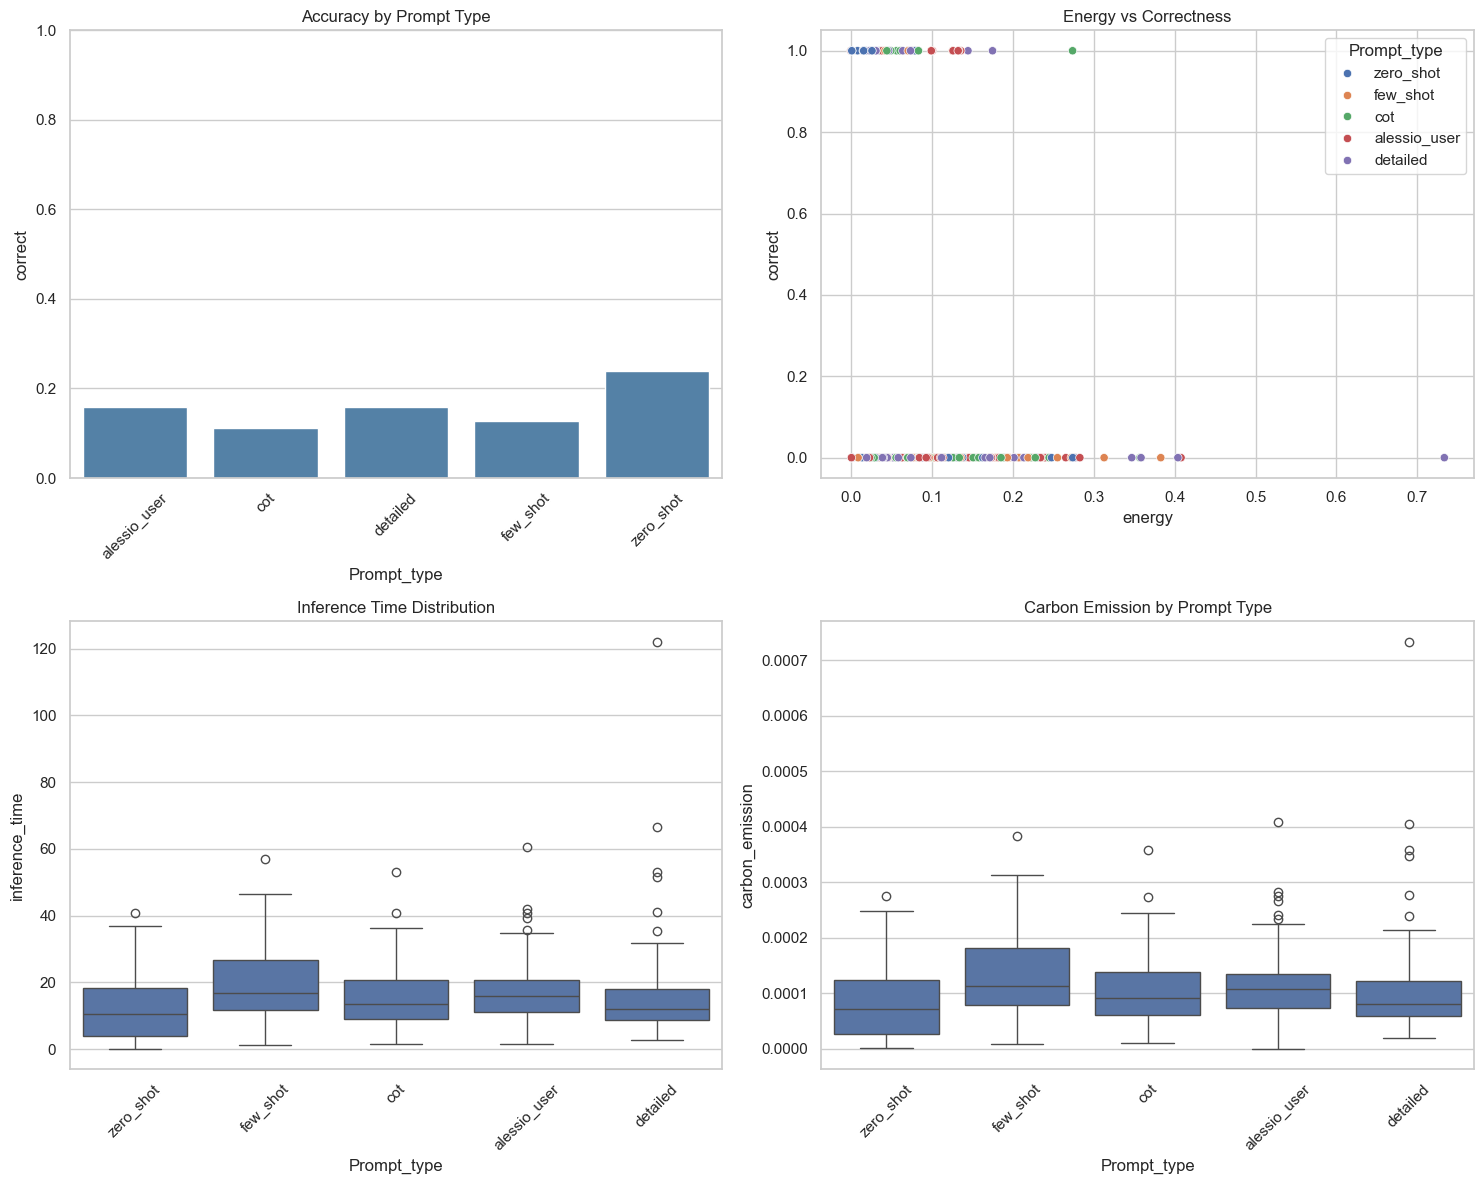

In [10]:
metrics_df = compute_group_accuracy(results_df)
metrics_df.to_csv("results/group_metrics.csv", index=False)

print(metrics_df)

print("Experiment Complete")

generate_plots(results_df)


In [3]:
# Generate Prompt Variants (30 each)

from prompts import BASE_PROMPTS, generate_prompt_variations, count_tokens

PROMPT_VARIANTS_PER_TYPE = 30
VARIANTS_OUTPUT_FOLDER = "prompt_variations"
os.makedirs(VARIANTS_OUTPUT_FOLDER, exist_ok=True)

def generate_prompt_experiment():
    print("\nGenerating prompt variants...")

    for prompt_type, base_prompt in tqdm(BASE_PROMPTS.items(), desc="Prompt Types", leave=True):
        if prompt_type == 'alessio_system':
            continue

        records = []
        for i in tqdm(range(PROMPT_VARIANTS_PER_TYPE), desc=f"{prompt_type} Variants", leave=True):
            sample_text = f"Sample requirement text number {i + 1}."
            variants = generate_prompt_variations(base_prompt, sample_text)
            for v in variants:
                records.append({
                    'Prompt_type': prompt_type,
                    'Iteration_number': i,
                    'Prompt_variant': v['prompt'],
                    'Token_Length': v['token_count'],
                    'Length_type': v['type'],
                    'Prompt_complexity': v['complexity']
                })

        df = pd.DataFrame(records)
        output_file = f"{VARIANTS_OUTPUT_FOLDER}/{prompt_type}_variants.csv"
        df.to_csv(output_file, index=False)
        print(f"\nSaved {output_file} with {len(records)} prompts.")

# Generate 30 Prompt Variants per type
generate_prompt_experiment()


Generating prompt variants...


zero_shot Variants: 100%|██████████| 30/30 [00:00<00:00, 14367.34it/s]



Saved prompt_variations/zero_shot_variants.csv with 270 prompts.


few_shot Variants: 100%|██████████| 30/30 [00:00<00:00, 11141.24it/s]



Saved prompt_variations/few_shot_variants.csv with 270 prompts.


...


Saved prompt_variations/cot_variants.csv with 270 prompts.


Prompt Types:  83%|████████▎ | 5/6 [00:00<00:00, 33.43it/s]


Saved prompt_variations/alessio_user_variants.csv with 270 prompts.


Prompt Types: 100%|██████████| 6/6 [00:00<00:00, 35.30it/s]


Saved prompt_variations/detailed_variants.csv with 270 prompts.
